# Tutorial II: Accessibility and emissions with `cafein`

## Getting started

There are three options to run the codes in this tutorial:

1. Copy-paste the codes from the website and run them line by line on your own computer with your preferred IDE (JupyterLab, Spyder, PyCharm, etc.).
2. Download this Notebook (see below) and run it in JupyterLab, which you have installed by following the [installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html).
3. Run the codes in Binder (see below). This needs no installation, but Binder has very limited computational resources, and the analyses in this tutorial need more memory than Binder offers.

### Download the Notebook

You can download this tutorial Notebook to your own computer by clicking the **Download button** from the menu on the top-right section of the website.

- Right-click the option that says `.ipynb` and choose **"Save link as .."**

![Download tutorial Notebook.](../img/Download_notebook_button.png)

### Run the codes on your own computer

Before you can run this Notebook, you need to launch the JupyterLab programming environment, which comes with the course environment (if you have not installed it yet, follow the [installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html)). To run JupyterLab:

1. Using the terminal or command prompt, change to the folder where you downloaded the Notebook: `$ cd /mydirectory/`
2. Activate the course environment: `$ conda activate sumogis`
3. Launch JupyterLab: `$ jupyter lab`

After these steps, the JupyterLab interface opens in your browser, and you can start executing cells (see the hints below at "Working with Jupyter Notebooks").

#### Alternatively: Run codes in Binder (with limited resources)

You can also run this Notebook by launching a Binder instance from the buttons at the top-right of this page, which look like this:

![Launch Binder](../img/launch_binder.png)

Building the routable networks of this tutorial takes roughly 5 GB of memory, so expect the larger examples to fail in Binder. We recommend running the Notebook on your own computer.

### Working with Jupyter Notebooks

Jupyter Notebooks are documents that combine computer code with rich text elements (such as text, figures, tables and links), and you run them inside the JupyterLab programming environment.

**A couple of hints**:

- You can **execute a cell** by clicking a given cell that you want to run and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd> (or by clicking the "Play" button on top).
- You can **change the cell type** between `Markdown` (for writing text) and `Code` (for writing and executing code) from the dropdown menu above.

See **further details and help for** [**using Notebooks and JupyterLab from here**](https://pythongis.org/part1/chapter-01/nb/04-using-jupyterlab.html).

## Introduction

**cafein** (*Cost of Access For Environment and INdividuals*) is a Python library for routing on multimodal transport networks (walking, cycling, driving and public transport). In addition to travel times, `cafein` reports the distance travelled on each leg of a journey and the **greenhouse-gas emissions** that the journey causes. This makes it possible to study the accessibility of places and the environmental cost of reaching them with the same tool.

`cafein` works with `geopandas` GeoDataFrames: you give the origins and destinations as GeoDataFrames, and you get the results back as tables that you can join to your spatial data. In this tutorial and in the Munich case study that continues it, we will also use three companion libraries:

- `cafein.sampledata` downloads ready-made sample datasets for the Helsinki region.
- `cafein.lca` calculates life-cycle emission factors for different transport modes, which we can use instead of the default factors of `cafein`.
- `transitio` downloads OpenStreetMap and public transport schedule data for any area of interest.

## Data requirements

### Data for creating a routable network

When calculating travel times with `cafein`, you typically need a couple of datasets:

- **A street network dataset from OpenStreetMap** (OSM) in Protocolbuffer Binary (`.pbf`) format:
  - This data is used for finding the fastest routes and calculating the travel times by walking, cycling and driving. In addition, `cafein` uses it for the walking legs to and from the stops, and between stops, when routing with public transport.
- **A transit schedule dataset** in General Transit Feed Specification (GTFS) format:
  - This data contains the information needed for routing with public transport, such as the stops, routes, trips and the times when the vehicles pass a specific stop. You can read about the [GTFS standard from here](https://gtfs.org/documentation/schedule/reference/).
  - `cafein` can also combine several GTFS feeds into one network, e.g. when the bus and the rail connections of a region are published separately.

### Data for origin and destination locations

In addition to the OSM and GTFS datasets, you need data that represents the origin and destination locations of the trips. This data is typically stored in a spatial data format, such as GeoPackage or GeoJSON. As `cafein` reads the locations from GeoDataFrames, you can use any data that you can read with `geopandas`.

### Where to get these datasets?

- **OpenStreetMap data in PBF format**:
  - [transitio](https://transitio.readthedocs.io) and [pyrosm](https://pyrosm.readthedocs.io/en/latest/basics.html#protobuf-file-what-is-it-and-how-to-get-one) libraries download and crop the data for your area of interest directly from Python (based on GeoFabrik, BBBike and other providers).
  - [GeoFabrik](http://download.geofabrik.de/) and [BBBike](https://download.bbbike.org/osm/bbbike/) websites have ready-made extracts for countries, regions and cities.
- **GTFS data**:
  - The [transitio](https://transitio.readthedocs.io) library finds the GTFS feeds that serve a given place, downloads them and crops them to your area of interest. We will use it in the Munich case study that continues this tutorial.
  - The [Mobility Database](https://mobilitydatabase.org/) and [Transitland](https://www.transit.land/operators) websites list GTFS feeds from around the world.

### Sample datasets

In the following tutorial, we use open datasets for the Helsinki region from `cafein.sampledata`:

- The street network is an extract of OpenStreetMap (© OpenStreetMap contributors, [ODbL license](https://www.openstreetmap.org/copyright)).
- The GTFS dataset is the public transport schedule of Helsinki Region Transport (HSL), licensed under [Creative Commons BY 4.0](https://www.hsl.fi/hsl/avoin-data#aineistojen-kayttoehdot).
- The population grid is from [Helsinki Region Environmental Services](https://www.hsy.fi/en/environmental-information/open-data/avoin-data---sivut/population-grid-of-helsinki-metropolitan-area/) (HSY), licensed under Creative Commons BY 4.0.
- The elevation model is from the National Land Survey of Finland, licensed under Creative Commons BY 4.0.
- The libraries are extracted from the same OpenStreetMap data (ODbL).

## Getting started with `cafein`

In this tutorial, we will learn how to calculate travel times and emissions with `cafein` in the Helsinki region, Finland.

### Load and prepare the origin and destination data

Let's start by reading a population grid into a geopandas `GeoDataFrame` that we can use as our destination locations. The helper `cafein.sampledata.helsinki` downloads the sample datasets for Helsinki the first time you use them and stores them on your computer, so the following runs are fast. Each dataset is a path to a file:

In [1]:
import geopandas as gpd
import cafein
import cafein.sampledata.helsinki as helsinki

# Read the population grid
pop_grid = gpd.read_file(helsinki.population_grid)

# Show the first rows of the most relevant columns
pop_grid[["id", "asukkaita", "geometry"]].head()

,id,asukkaita,geometry
0,Vaestotietoruudukko_2025.1,6,"POLYGON ((362054.365 6689582.191, 362061.946 6..."
1,Vaestotietoruudukko_2025.2,6,"POLYGON ((361940.674 6685834.568, 361948.252 6..."
2,Vaestotietoruudukko_2025.3,6,"POLYGON ((361887.631 6684085.685, 361895.208 6..."
3,Vaestotietoruudukko_2025.4,6,"POLYGON ((361880.054 6683835.845, 361887.631 6..."
4,Vaestotietoruudukko_2025.5,8,"POLYGON ((361849.748 6682836.473, 361857.325 6..."


As we can see, the population grid covers the Helsinki region with 250 x 250 meter cells. The `id` column contains a unique identifier for each cell, and the `asukkaita` column contains the number of residents living in each cell (the column names are in Finnish). `cafein` needs a unique `id` column for the origins and destinations, so this dataset is ready to use as such.

Let's see how many cells there are and how the residents are distributed in the region:

In [2]:
print(f"Number of grid cells: {len(pop_grid)}")
print(f"Number of residents: {pop_grid['asukkaita'].sum()}")

Number of grid cells: 5825
Number of residents: 1253793


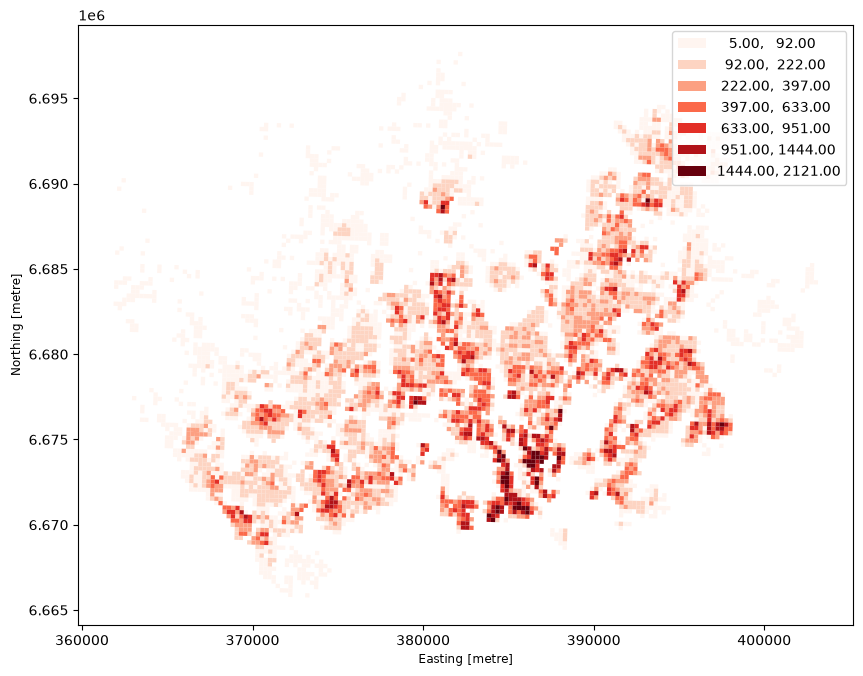

In [3]:
# Plot the number of residents in each grid cell
pop_grid.plot(column="asukkaita", cmap="Reds", scheme="natural_breaks", k=7, legend=True, figsize=(10, 8));

#### Convert polygon layer to points

Next, we convert the polygons into points by calculating the centroid of each cell. `cafein` could also route from the polygons directly (it then uses their centroids), but having the points as their own layer makes it explicit which locations we route between. We also reproject the points into WGS84 coordinates (EPSG:4326), which `cafein` uses for its inputs and outputs:

In [4]:
# Make a copy of the grid and replace the polygons with their centroids
points = pop_grid.copy()
points["geometry"] = points.centroid

# Reproject the points to WGS84
points = points.to_crs(epsg=4326)

points[["id", "asukkaita", "geometry"]].head(3)

,id,asukkaita,geometry
0,Vaestotietoruudukko_2025.1,6,POINT (24.50461 60.32041)
1,Vaestotietoruudukko_2025.2,6,POINT (24.50512 60.28675)
2,Vaestotietoruudukko_2025.3,6,POINT (24.50535 60.27105)


#### Retrieve the origin location by geocoding an address

Let's geocode the address of the Helsinki Railway Station with `osmnx` and use it as our **origin** location:

In [5]:
import osmnx as ox
from shapely.geometry import Point

# Geocode the address of the railway station
lat, lon = ox.geocode("Rautatieasema, Helsinki")

# Create a GeoDataFrame with an id for the origin location
origin = gpd.GeoDataFrame(
    {"id": ["station"], "name": ["Helsinki Railway Station"]},
    geometry=[Point(lon, lat)],
    crs="EPSG:4326",
)

# Show the origin on a map
origin.explore(color="red", marker_kwds={"radius": 12}, max_zoom=14)

### Build the transport network

Virtually all operations of `cafein` need a transport network. We build one from the GTFS data and the OpenStreetMap extract with `cafein.TransportNetwork.from_gtfs()`. Under the hood, `cafein` reads the public transport schedules, snaps the stops to the street network, and builds the walking paths that connect stops to each other and to any coordinate we route from. This takes a minute or two:

In [6]:
%%time
# Build the routable network from the GTFS and OpenStreetMap data
network = cafein.TransportNetwork.from_gtfs(helsinki.gtfs, osm_pbf=helsinki.osm_pbf)

.../site-packages/cafein/streets.py:374: UserWarning: 1009 stop(s) are farther than 1600.0 m from the walking network and get no footpaths
  snapped = _snap_to_edges(stop_points, edges, max_snap_distance)


CPU times: user 30.3 s, sys: 2.6 s, total: 32.9 s
Wall time: 30.8 s


Now the routable network is stored in the `network` variable. The warning tells that some stops lie far from any walkable street (e.g. stops on islands that the street extract does not cover); `cafein` leaves those stops without a walking connection.

A GTFS feed is valid only for a limited period of time, so the departure time of our trips needs to fall within the feed's service period. Let's check the period with the `service_window` attribute:

In [7]:
network.service_window

(datetime.date(2026, 8, 20), datetime.date(2026, 10, 18))

We will use Tuesday, 1 September 2026, at 8 AM as our departure time, which is inside the service window:

In [8]:
import datetime

# Departure time: Tuesday 1 September 2026 at 8 AM
departure = datetime.datetime(2026, 9, 1, 8, 0)

### Compute travel times and emissions from one to all locations

A **travel cost matrix** is a table that shows the travel costs (e.g. travel time and emissions) between given origins and destinations. We calculate one with `cafein.TravelCostMatrix`, which takes the network, the origins, the destinations and the departure time. With a `TransportNetwork`, `cafein` routes by public transport and walking:

In [9]:
# Calculate travel times and emissions from the railway station to all grid cells
travel_costs = cafein.TravelCostMatrix(network, origins=origin, destinations=points, departure=departure)

travel_costs.head()

.../site-packages/cafein/matrices.py:1193: UserWarning: no emission factor matches route_type(s) [4]; journeys riding the affected trips carry no emissions
  emissions.trip_factors(network, factors, components),


,from_id,to_id,travel_time,transfers,transit_distance_m,walk_distance_m,emissions
0,station,Vaestotietoruudukko_2025.1,84,1,40043.0,806.119352,2346.904
1,station,Vaestotietoruudukko_2025.2,89,1,37676.0,1116.717275,2129.140
2,station,Vaestotietoruudukko_2025.3,86,1,34420.0,1277.658010,1829.588
3,station,Vaestotietoruudukko_2025.4,84,1,34420.0,1132.672705,1829.588
4,station,Vaestotietoruudukko_2025.5,103,1,33030.0,2460.262238,1701.708


As a result, we get a `pandas.DataFrame` with one row per origin-destination pair:

| Column | Description |
| ------ | ----------- |
| `from_id`, `to_id` | The ids of the origin and the destination |
| `travel_time` | The door-to-door travel time in minutes (including walking and waiting) |
| `transfers` | The number of transfers between public transport vehicles |
| `transit_distance_m` | The distance travelled in public transport vehicles in meters |
| `walk_distance_m` | The distance walked in meters |
| `emissions` | The greenhouse-gas emissions of the trip in grams of CO₂ equivalent (g CO₂e) |

`cafein` calculates the emissions of each public transport leg by multiplying the distance travelled with an **emission factor** of the vehicle type (in g CO₂e per passenger-kilometer). By default, `cafein` uses life-cycle factors calibrated to the Finnish electricity mix, which suit our Helsinki data. Walking causes no emissions.

Let's take a look at the descriptive statistics of the results:

In [10]:
travel_costs.describe().round(1)

,travel_time,transfers,transit_distance_m,walk_distance_m,emissions
count,5825.0,5825.0,5825.0,5825.0,5812.0
mean,46.0,0.9,16289.6,893.2,741.8
std,18.4,0.5,7210.6,450.6,514.8
min,4.0,0.0,0.0,223.7,0.0
25%,34.0,1.0,11383.0,615.9,390.1
50%,43.0,1.0,15921.0,804.0,615.2
75%,54.0,1.0,21400.0,1043.2,955.0
max,143.0,3.0,42275.0,4696.2,2820.3


Notice that the `emissions` column has a few values fewer than the other columns. The fastest journeys to a handful of cells use the ferry to Suomenlinna, and `cafein` has no default emission factor for ferries, so it leaves the emissions of those journeys empty (`NaN`) and warns about it. We will come back to emission factors in the Munich case study that continues this tutorial.

Next, let's join the results to the population grid so that we can map them:

In [11]:
# Join the travel costs to the population grid
grid_costs = pop_grid.merge(travel_costs, left_on="id", right_on="to_id")

grid_costs[["id", "asukkaita", "travel_time", "emissions"]].head()

,id,asukkaita,travel_time,emissions
0,Vaestotietoruudukko_2025.1,6,84,2346.904
1,Vaestotietoruudukko_2025.2,6,89,2129.140
2,Vaestotietoruudukko_2025.3,6,86,1829.588
3,Vaestotietoruudukko_2025.4,6,84,1829.588
4,Vaestotietoruudukko_2025.5,8,103,1701.708


Now we have the travel times and emissions attached to each grid cell, and we can visualize them side by side:

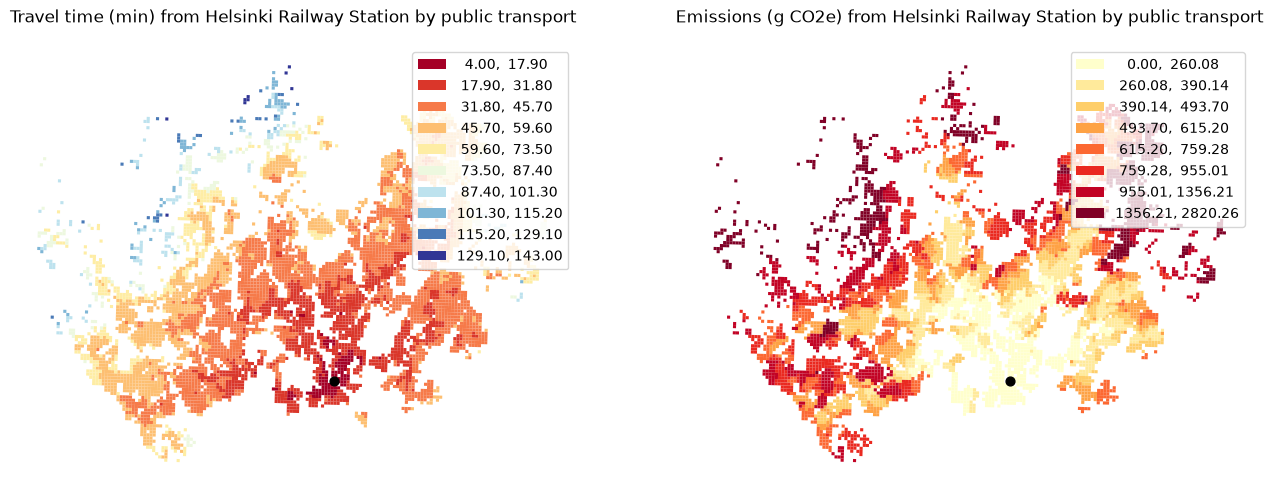

In [12]:
import matplotlib.pyplot as plt

# Ensure that the origin location is in the same CRS as the grid
orig_projected = origin.to_crs(grid_costs.crs)

# Create a figure with two maps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot the travel times on the left
grid_costs.plot(ax=ax1, column="travel_time", cmap="RdYlBu", scheme="equal_interval", k=10, legend=True)
orig_projected.plot(ax=ax1, color="black", markersize=40)
ax1.set_title("Travel time (min) from Helsinki Railway Station by public transport")
ax1.set_axis_off()

# Plot the emissions on the right
grid_costs.plot(ax=ax2, column="emissions", cmap="YlOrRd", scheme="quantiles", k=8, legend=True)
orig_projected.plot(ax=ax2, color="black", markersize=40)
ax2.set_title("Emissions (g CO2e) from Helsinki Railway Station by public transport")
ax2.set_axis_off()

As we can see, the travel times grow with the distance from the railway station, but they also follow the metro and the commuter rail lines, along which you can travel far within a short time. The emissions grow mainly with the distance travelled in vehicles, and they also depend on the vehicle type: buses cause more emissions per passenger-kilometer than electric trains, metro and trams.

### Compute travel times from all to all locations

Let's continue by calculating travel times between all locations. Routing between all 5,825 grid cells would mean almost 34 million origin-destination pairs, so we use a coarser grid for this example. The `cafein.zones` module creates a grid of [H3 hexagons](https://h3geo.org/) that covers a given area. At **resolution** 8, each hexagon covers roughly 0.74 km²:

In [13]:
from cafein import zones

# Create a grid of H3 hexagons at resolution 8 that covers the population grid
hexagons = zones.h3_grid(pop_grid, 8)

hexagons.head(3)

,id,centroid_lat,centroid_lon,geometry
0,8808996049fffff,60.306037,24.532448,"POLYGON ((24.52487 60.30468, 24.5305 60.30163,..."
1,880899604dfffff,60.298574,24.536127,"POLYGON ((24.52855 60.29721, 24.53418 60.29416..."
2,8808996065fffff,60.280252,24.569880,"POLYGON ((24.5623 60.2789, 24.56793 60.27584, ..."


In [14]:
print(f"Number of hexagons: {len(hexagons)}")

Number of hexagons: 1240


The hexagon grid has an `id` column, and `cafein` routes from the hexagons' centroids (the `centroid_lat` and `centroid_lon` columns). Now we can use the same hexagons as the origins and the destinations:

In [15]:
%%time
# Calculate travel times between all hexagons
all_to_all = cafein.TravelCostMatrix(network, origins=hexagons, destinations=hexagons, departure=departure)

.../site-packages/cafein/matrices.py:1193: UserWarning: no emission factor matches route_type(s) [4]; journeys riding the affected trips carry no emissions
  emissions.trip_factors(network, factors, components),


CPU times: user 1min 4s, sys: 453 ms, total: 1min 4s
Wall time: 8.27 s


In [16]:
print(f"Number of origin-destination pairs: {len(all_to_all)}")

Number of origin-destination pairs: 1522764


To estimate how well each hexagon is connected to the rest of the region, we calculate the median travel time from each hexagon to all others:

In [17]:
# Calculate the median travel time from each hexagon to all other hexagons
median_times = all_to_all.groupby("from_id")["travel_time"].median()
median_times = median_times.rename("median_travel_time")

# Join the median travel times to the hexagons
overall_access = hexagons.merge(median_times, left_on="id", right_index=True)

# Plot the median travel times on an interactive map
overall_access.explore("median_travel_time", cmap="Blues", scheme="natural_breaks", k=5, tiles="Esri.WorldGrayCanvas")

In [18]:
print(f"Mean of the median travel times: {overall_access['median_travel_time'].mean():.1f} minutes")

Mean of the median travel times: 86.2 minutes


The hexagons in the city center and along the rail lines have the shortest median travel times to the rest of the region, while the hexagons on the edges of the region have the longest ones (a classic **edge effect**: the region's own boundary limits where people can travel to).

## Detailed itineraries

The travel cost matrix tells how long a trip takes, but not which route it takes. `cafein.DetailedItineraries` returns the full journeys, with one row per **leg** of each journey (walking to a stop, riding a vehicle, transferring, walking to the destination). Let's geocode three destinations in different parts of the region (Tapiola in Espoo, Itäkeskus in eastern Helsinki and Tikkurila in Vantaa) and calculate the journeys to them from the railway station:

In [19]:
# The places to use as destinations
places = {"Tapiola": "Tapiola, Espoo", "Itäkeskus": "Itäkeskus, Helsinki", "Tikkurila": "Tikkurila, Vantaa"}

# Geocode the places and create a GeoDataFrame out of them
coordinates = [ox.geocode(query) for query in places.values()]
geometries = [Point(lon, lat) for lat, lon in coordinates]
destinations = gpd.GeoDataFrame({"id": list(places)}, geometry=geometries, crs="EPSG:4326")

# Calculate the detailed itineraries from the railway station to the destinations
itineraries = cafein.DetailedItineraries(network, origins=origin, destinations=destinations, departure=departure)

# Show the first legs without the geometry column
itineraries.drop(columns="geometry").head(10)

,from_id,to_id,option,segment,leg_type,departure_s,arrival_s,travel_time,from_stop,to_stop,trip_id,route_id,route_short_name,distance_m,distance_provenance,emissions
0,station,Tapiola,0,0,access,28800,28978,3,NaN,1020602,NaN,NaN,NaN,177.015238,NaN,0.000
1,station,Tapiola,0,1,transit,28980,29820,14,1020602,2211602,31M2_20260820_Ti_2_0742,31M2,M2,10377.000000,shape_dist,259.425
2,station,Tapiola,0,2,egress,29820,30123,5,2211602,NaN,NaN,NaN,NaN,302.567090,NaN,0.000
3,station,Itäkeskus,0,0,access,28800,28979,3,NaN,1020601,NaN,NaN,NaN,178.149226,NaN,0.000
4,station,Itäkeskus,0,1,transit,28980,29880,15,1020601,1453601,31M2_20260820_Ti_1_0748,31M2,M2,10266.000000,shape_dist,256.650
5,station,Itäkeskus,0,2,transfer,29880,29903,0,1453601,1000111,NaN,NaN,NaN,22.574574,NaN,0.000
6,station,Itäkeskus,0,3,egress,29903,30149,4,1000111,NaN,NaN,NaN,NaN,245.914848,NaN,0.000
7,station,Tikkurila,0,0,access,28800,28924,2,NaN,1020501,NaN,NaN,NaN,123.589368,NaN,0.000
8,station,Tikkurila,0,1,transit,29400,30240,14,1020501,4610504,3001R_20260823_Ti_1_0810,3001R,R,15710.000000,shape_dist,392.750
9,station,Tikkurila,0,2,egress,30240,30665,7,4610504,NaN,NaN,NaN,NaN,424.693445,NaN,0.000


As we can see, the result contains much more information than the travel cost matrix:

| Column | Description |
| ------ | ----------- |
| `option` | The number of the alternative journey between the origin and the destination |
| `segment` | The order of the leg within the journey |
| `leg_type` | The type of the leg: `access` (walking to the first stop), `transit`, `transfer`, `egress` (walking from the last stop) or `walk` (walking all the way) |
| `departure_s`, `arrival_s` | The departure and arrival times in seconds since midnight |
| `travel_time` | The duration of the leg in minutes |
| `from_stop`, `to_stop` | The stops where a transit leg starts and ends |
| `trip_id`, `route_id`, `route_short_name` | The vehicle trip and the line used on a transit leg |
| `distance_m` | The distance of the leg in meters |
| `distance_provenance` | How the distance was measured: e.g. `shape_dist` means along the route geometry of the GTFS feed |
| `emissions` | The emissions of the leg in g CO₂e |
| `geometry` | The geometry of the leg |

The result is a GeoDataFrame, so we can draw the journeys on a map right away. Hover over the lines to see the details of each leg:

In [20]:
# Label each leg with its type and the line number
itineraries["leg"] = itineraries["leg_type"] + " " + itineraries["route_short_name"].fillna("")

# Plot the legs on an interactive map
m = itineraries.explore(
    column="leg",
    tooltip=["option", "leg", "travel_time", "distance_m", "emissions"],
    style_kwds={"weight": 5},
    cmap="Reds",
    tiles="Esri.WorldGrayCanvas",
)

# Add the railway station to the same map
origin.explore(m=m, color="black", marker_kwds={"radius": 8})

## Fastest vs. lowest-emission journeys

The fastest journey is not always the one with the lowest emissions. A slightly slower journey by metro or tram can, for example, cause less emissions than a faster bus connection. With `candidates="pareto"`, `DetailedItineraries` returns all journeys for which no other journey is both faster and cleaner (the so-called **Pareto set**). Let's calculate them for the trip to Tapiola:

In [21]:
# Find the journeys to Tapiola for which no other journey is both faster and cleaner
pareto = cafein.DetailedItineraries(
    network, origins=origin, destinations=destinations.head(1), departure=departure, candidates="pareto"
)

# Compare each journey with the fastest one
journeys = cafein.compare_to_fastest(pareto)

journeys.head(8)

.../site-packages/cafein/itineraries.py:968: UserWarning: no emission factor matches route_type(s) [4]; journeys riding the affected trips carry no emissions
  emissions.trip_factors(network, transit_factors, components)


,from_id,to_id,option,travel_time,emissions,distance_m,fastest,travel_time_delta,emissions_delta,distance_m_delta
0,station,Tapiola,0,22,259.425,10856.582328,True,0.0,0.000,0.000000
1,station,Tapiola,1,29,246.125,10877.031829,False,7.0,-13.300,20.449502
2,station,Tapiola,2,38,223.948,9572.069543,False,16.0,-35.477,-1284.512785
3,station,Tapiola,3,42,190.000,9527.873440,False,20.0,-69.425,-1328.708888
4,station,Tapiola,4,60,166.375,9633.756384,False,38.0,-93.050,-1222.825944
5,station,Tapiola,5,67,148.850,9575.891726,False,45.0,-110.575,-1280.690602
6,station,Tapiola,6,80,120.375,9265.888768,False,58.0,-139.050,-1590.693559
7,station,Tapiola,7,95,95.175,9173.687108,False,73.0,-164.250,-1682.895219


The `compare_to_fastest()` function sums the legs of each journey and compares the journeys with the fastest one: `travel_time_delta` tells how many minutes longer a journey takes, and `emissions_delta` how many grams of CO₂e it saves (negative values) compared to the fastest journey. As we can see, the fastest trip to Tapiola takes 22 minutes by metro and causes about 260 g CO₂e. The cleaner alternatives exist, but they cost extra travel time: the journey that takes 20 minutes longer saves about a quarter of the emissions, and the cleanest journey in the table takes over an hour longer. This way, we can see how much extra travel time a traveler would need to accept to reduce the emissions of their trip.

`TravelCostMatrix` can also report the lowest-emission journey for every origin-destination pair instead of the fastest one, with the parameter `optimize="emissions"`. It then searches the journeys that depart within a given time window (`departure_time_window`, in minutes), optionally limited by a maximum travel time (`max_travel_time`).

## Cycling with elevation

`cafein` can also route by walking, cycling and driving. For these modes, we build a `cafein.StreetNetwork` from the OpenStreetMap data. When we also give it an **elevation model** (a raster of terrain heights), `cafein` adjusts the cycling speeds to the slopes: riding uphill is slower than riding downhill. Let's first read the DEM for Helsinki and explore how it looks like on a map:

In [22]:
import numpy as np
import xarray as xr

grid = (
    xr.open_dataset(helsinki.dem, engine="rasterio", masked=True, band_as_variable=True)
    .rename({"band_1": "elevation"})
    .assign(elevation=lambda ds: ds["elevation"]
            .where(ds["elevation"] <= 230)
            .rio.write_nodata(np.nan))
)
grid

<xarray.Dataset> Size: 106MB
Dimensions:      (x: 5010, y: 5280)
Coordinates:
  * x            (x) float64 40kB 3.547e+05 3.547e+05 ... 4.048e+05 4.048e+05
  * y            (y) float64 42kB 6.7e+06 6.7e+06 ... 6.647e+06 6.647e+06
    spatial_ref  int64 8B ...
Data variables:
    elevation    (y, x) float32 106MB 60.0 60.0 60.0 60.0 ... nan nan nan nan
Attributes:
    AREA_OR_POINT:  Area

Now we can visualize the elevation data on a map. A **colormap** defines how numeric values are translated into colors. Here we use the `bukavu` colormap from the `cmcrameri` library, which provides Fabio Crameri's perceptually uniform scientific colormaps. `bukavu` is designed for topography: its lower half contains blue tones for the sea, and its upper half contains green-to-brown tones for land. It is included in the course environment.

Because the sea areas in our data have an elevation of 0, we first mask them out with `.where(e > 0)` and color the land using only the upper half of the colormap. We then set the plot background to a blue tone from the lower half, so that the masked sea areas, including the missing tiles in the southeast, appear as water:

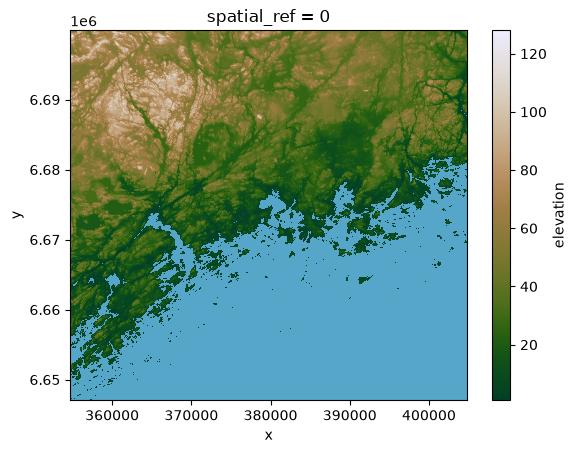

In [23]:
import numpy as np
from matplotlib.colors import ListedColormap
import cmcrameri.cm as cmc

e = grid["elevation"]
im = e.where(e > 0).plot(cmap=ListedColormap(cmc.bukavu(np.linspace(0.5, 1, 256))))
im.axes.set_facecolor(cmc.bukavu(0.3))

Let's now build a cycling network with the elevation model of the Helsinki region:

In [24]:
%%time
# Build a cycling network that adjusts the cycling speeds to the slopes
bike_network = cafein.StreetNetwork.from_osm(helsinki.osm_pbf, modes=["bicycle"], dem=helsinki.dem)

CPU times: user 9.64 s, sys: 1.11 s, total: 10.8 s
Wall time: 10.3 s


Now we can calculate the cycling travel times in the same way as before. With a `StreetNetwork`, we tell the mode with the `transport_mode` parameter:

In [25]:
# Calculate the cycling travel times from the railway station to all grid cells
bike_costs = cafein.TravelCostMatrix(bike_network, origins=origin, destinations=points, transport_mode="bicycle")

bike_costs.head()

,from_id,to_id,travel_time,distance_m,network_distance_m,connector_distance_m,distance_provenance,emissions
0,station,Vaestotietoruudukko_2025.23,119,27908.587151,27823.907724,84.679427,osm_edge_length+geodesic_connector,1029.484586
1,station,Vaestotietoruudukko_2025.24,118,27943.251765,27892.301097,50.950667,osm_edge_length+geodesic_connector,1032.015141
2,station,Vaestotietoruudukko_2025.25,118,28005.172610,27977.074405,28.098205,osm_edge_length+geodesic_connector,1035.151753
3,station,Vaestotietoruudukko_2025.29,118,27734.586320,27647.490724,87.095596,osm_edge_length+geodesic_connector,1022.957157
4,station,Vaestotietoruudukko_2025.30,119,27926.844709,27835.533724,91.310985,osm_edge_length+geodesic_connector,1029.914748


For street modes, the result reports the distance (`distance_m`) instead of the transit and walking distances. The emissions of cycling are not zero: the default factor of `cafein` includes the manufacturing of the bike and the extra food that cycling requires.

Let's compare cycling with public transport and see where cycling is the faster option:

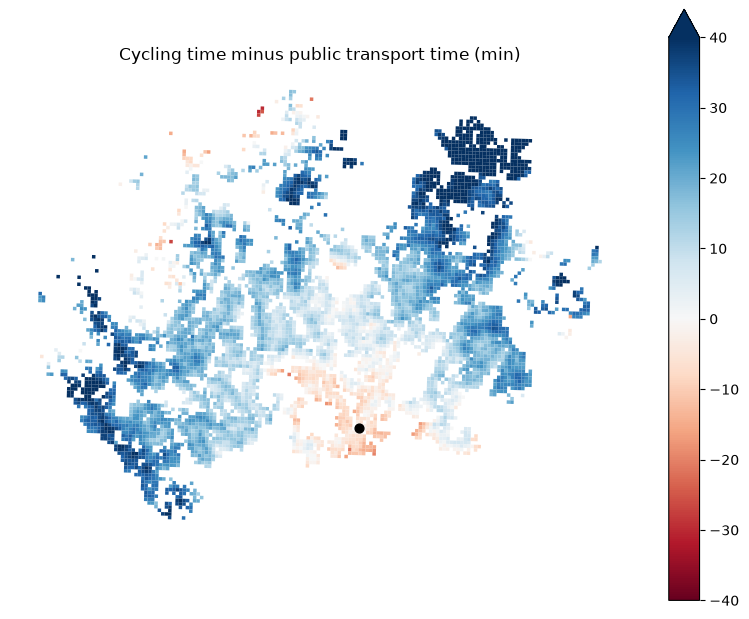

In [26]:
# Combine transit and cycling data into a single frame
modes = travel_costs[["to_id", "travel_time"]].merge(bike_costs[["to_id", "travel_time"]], on="to_id", suffixes=("_pt", "_bike"))

# Calculate the difference
modes["bike_minus_pt"] = modes["travel_time_bike"] - modes["travel_time_pt"]

# Merge the data with the population grid
grid_modes = pop_grid.merge(modes, left_on="id", right_on="to_id")

# Ensure that the origin location is in the same CRS as grid
orig_projected = origin.to_crs(grid_modes.crs)

# Plot
ax = grid_modes.plot(column="bike_minus_pt", cmap="RdBu", vmin=-40, vmax=40, legend=True, figsize=(10, 8))
orig_projected.plot(ax=ax, color="black", markersize=40)

# Add title and remove axis
ax.set_title("Cycling time minus public transport time (min)")
ax.set_axis_off();

In [27]:
print(f"Cycling is faster to {(grid_modes['bike_minus_pt'] < 0).mean():.0%} of the grid cells")

Cycling is faster to 10% of the grid cells


The blue cells are faster to reach by bike and the red ones by public transport. Within a few kilometers from the railway station, cycling is typically as fast as or faster than public transport, while public transport wins the long trips along the metro and rail lines.

## Calculate catchment areas

One typical accessibility analysis is to find out the **catchment area** of each service location, such as a library: the area from which the library is the closest one to reach. Let's read the libraries of the Helsinki region from the sample data:

In [28]:
# Read library data and assign an id for each feature
libraries = gpd.read_file(helsinki.pois.library)
libraries["id"] = libraries["osm_id"].astype(str)

# Compute centroid (round trip via a projected CRS)
libraries["geometry"] = libraries.to_crs(epsg=3067).centroid.to_crs(epsg=4326)
libraries.explore(color="red", marker_kwds={"radius": 5})

In [29]:
print(f"Number of libraries: {len(libraries)}")

Number of libraries: 102


`cafein.NearestDestinations` finds the closest destinations (here, the closest library) for each origin. Here we use the grid cells as the origins, so that `cafein` routes from each cell's centroid:

In [30]:
%%time
# The grid cells as polygons in WGS84 (cafein routes from their centroids)
grid_wgs84 = pop_grid.to_crs(epsg=4326)

# Find the closest library for each grid cell
nearest = cafein.NearestDestinations(network, origins=grid_wgs84, destinations=libraries, departure=departure, k=1)

nearest.head()

CPU times: user 4min 21s, sys: 1.33 s, total: 4min 22s
Wall time: 28.9 s


,from_id,rank,destination_id,cost
0,Vaestotietoruudukko_2025.1,1,8911452721,51.0
1,Vaestotietoruudukko_2025.2,1,8911452721,59.0
2,Vaestotietoruudukko_2025.3,1,8911452721,59.0
3,Vaestotietoruudukko_2025.4,1,8911452721,59.0
4,Vaestotietoruudukko_2025.5,1,8911452721,29.0


The result tells for each grid cell (`from_id`) the closest library (`destination_id`) and the travel time to it in minutes (`cost`). The `dominance_areas()` method dissolves the grid cells by their closest library, which gives us the catchment areas:

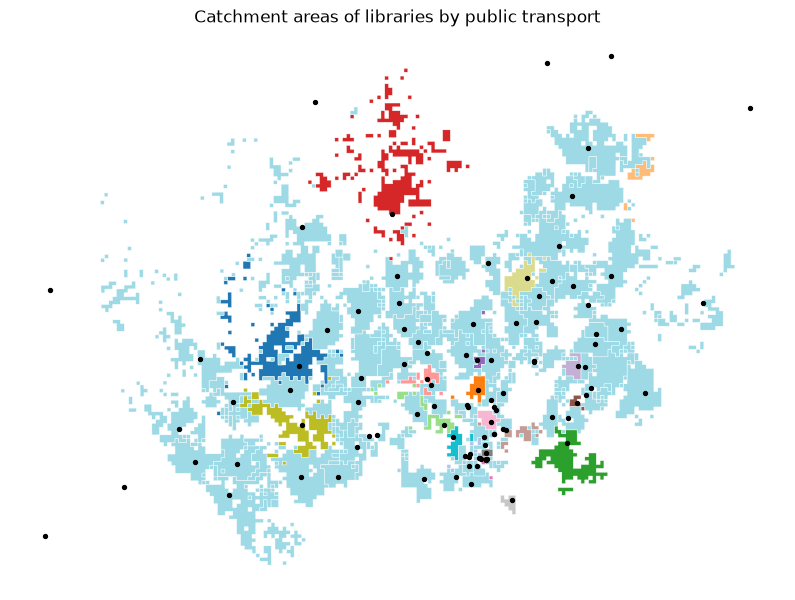

In [31]:
# Dissolve the grid cells by their closest library
catchments = nearest.dominance_areas(grid_wgs84)

# Plot the catchment areas and the libraries
ax = catchments.plot(column="destination_id", cmap="tab20", edgecolor="white", linewidth=0.3, figsize=(10, 8))
libraries.plot(ax=ax, color="black", markersize=8)

# Add title and remove axis
ax.set_title("Catchment areas of libraries by public transport")
ax.set_axis_off();

## Analyze accessibility

After we have calculated the travel times to the closest services, we can start analyzing accessibility. There are various ways to analyze how accessible services are. Let's first calculate how many residents can reach a library within 15 minutes by public transport or walking:

In [32]:
# Travel time threshold in minutes
threshold = 15

# Join the travel times to the closest library with the population grid
grid_nearest = pop_grid.merge(nearest, left_on="id", right_on="from_id")

# Select the grid cells from which a library can be reached within the threshold
within = grid_nearest.loc[grid_nearest["cost"] <= threshold]

# Calculate the number and the share of residents in those grid cells
residents_within = within["asukkaita"].sum()
share = residents_within / pop_grid["asukkaita"].sum()

In [33]:
print(f"Residents within {threshold} minutes from a library: {residents_within} ({share:.0%})")

Residents within 15 minutes from a library: 742440 (59%)


With this information, we can start evaluating whether the level of access in the region is sufficient and equitable. Often the interesting question is "who does not have access?", i.e. who is left out. What counts as a reasonable travel time threshold depends on the service and on the travelers, and it is a question that requires careful consideration in each analysis.

## Cumulative opportunities

Another commonly used approach is to count how many services a person can reach within a given travel time budget. This is called the **cumulative opportunities** measure. `cafein.Accessibility` calculates it for several budgets at once:

In [34]:
%%time
# Count the libraries that can be reached within 15 and 30 minutes from each grid cell
access = cafein.Accessibility(network, origins=points, destinations=libraries, departure=departure, budgets=(15, 30))

access.head()

CPU times: user 4min 26s, sys: 1.61 s, total: 4min 28s
Wall time: 29.5 s


,from_id,opportunity,budget,accessibility
0,Vaestotietoruudukko_2025.1,count,15.0,0.0
1,Vaestotietoruudukko_2025.1,count,30.0,0.0
2,Vaestotietoruudukko_2025.2,count,15.0,0.0
3,Vaestotietoruudukko_2025.2,count,30.0,0.0
4,Vaestotietoruudukko_2025.3,count,15.0,0.0


The result is in a long format: one row per origin and budget, where `accessibility` is the number of libraries reachable within the budget (`budget`, in minutes). Let's map the number of libraries reachable within 30 minutes:

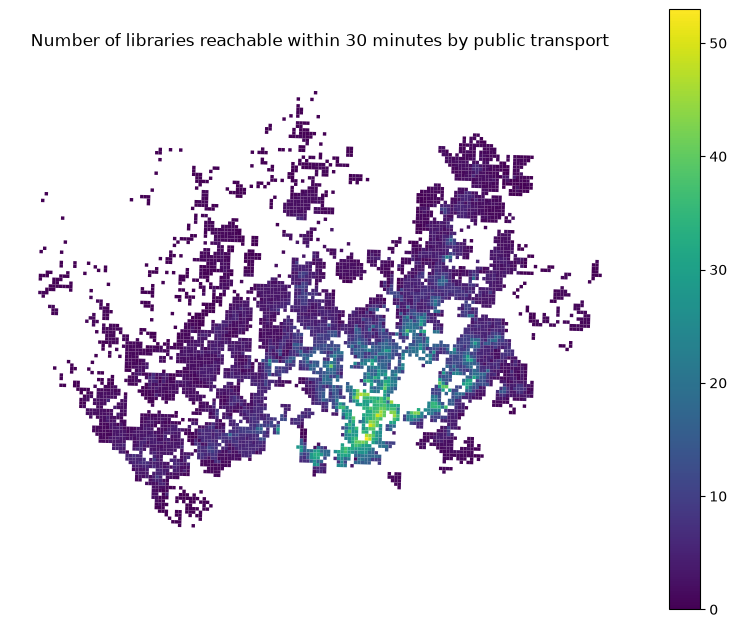

In [35]:
# Select the results for the 30-minute budget
access_30 = access.loc[access["budget"] == 30]

# Join the results with the population grid
access_30 = pop_grid.merge(access_30, left_on="id", right_on="from_id")

# Plot
ax = access_30.plot(column="accessibility", cmap="viridis", legend=True, figsize=(10, 8))

# Add title and remove axis
ax.set_title("Number of libraries reachable within 30 minutes by public transport")
ax.set_axis_off();

Now we can see the areas with the highest access to libraries. This measure is also called **Hansen's accessibility** after its developer. `Accessibility` can also give more weight to the closer services with a **distance decay** function (the `decay` parameter), which reflects that people are less likely to visit services that are further away.

Finally, `cafein.Catchment` shows how far you can get from a location within given travel time budgets. It returns the area reached as a union of H3 hexagons for each budget:

In [36]:
# Calculate the areas that can be reached within 15, 30 and 45 minutes from the railway station
reach = cafein.Catchment(network, origins=origin, departure=departure, budgets=(15, 30, 45))

# Convert the result into a GeoDataFrame and order the areas from the largest to the smallest
reach = gpd.GeoDataFrame(reach).sort_values("budget", ascending=False)

# Plot the areas on an interactive map
reach.explore(column="budget", cmap="viridis_r", style_kwds={"fillOpacity": 0.4})

## Where to go next?

Continue with the [Munich case study](cafein_munich.ipynb), where we apply `cafein` to a new city with data downloaded with `transitio`, and compare the travel times and emissions of public transport, cycling and driving.

In case you want to learn more, we recommend reading:

- [cafein repository](https://github.com/cafein-py/cafein), which includes more details on how to use `cafein`.
- [cafein.lca documentation](https://cafein-lca.readthedocs.io), which explains how the life-cycle emission factors are calculated.
- [transitio documentation](https://transitio.readthedocs.io), which explains how to find and download OSM and GTFS data for any area.
- Levinson, D. & H. Wu (2020). [Towards a general theory of access.](https://www.jtlu.org/index.php/jtlu/article/view/1660)